# Pilot 2026 — model-ready dataset QC

## tl;dr

The campaign adapter gate is **PASS** for run `20260717T002514Z_ced2c8`. It contains
1,728 primary observations, 11,575
temperature input rows, 6,119 autocorrelation-weighted CO₂ bins,
234 wine-aroma observations, and
198 interval-condensate observations.

This is a data-contract pass, **not a calibration pass**. MassView reference conditions,
the 80 versus 90.435 mg/L YAN discrepancy, independent verification, and owner review
remain open. No profile in this notebook is approved for physical execution.


## Context & Methods

### Key Assumptions

- `Sonda1` is executed temperature; controller setpoint is the commanded input.
- Total glucose+fructose is omitted whenever either component is modeled, preventing
  duplicate likelihood contributions.
- Pilot Lot 1 CO₂ is QC-only and cannot enter the model table.
- CO₂ is aggregated in deterministic relative-time bins and weighted by a clipped
  lag-1 effective sample size.
- NQ and below-LOQ GC rows are interval-censored observations, not zero-valued points.
- Carbon recovery is diagnostic-only because biomass, unmeasured products, sampling
  losses, masked CO₂ intervals, and verified normal reference conditions are absent.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "fermentation_model" / "pilot_2026").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root")

REPO = find_repo_root(Path.cwd().resolve())
RUN_RELATIVE = 'fermentation_model/pilot_2026/results/adaptive_design_2026/model_dataset/20260717T002514Z_ced2c8'
RUN = REPO / RUN_RELATIVE
print(f"Run: {RUN_RELATIVE}")


Run: fermentation_model/pilot_2026/results/adaptive_design_2026/model_dataset/20260717T002514Z_ced2c8


## Data

In [2]:
qc = json.loads((RUN / "dataset_qc.json").read_text(encoding="utf-8"))
manifest = json.loads((RUN / "run_manifest.json").read_text(encoding="utf-8"))
primary = pd.read_csv(RUN / "primary_observations.csv", parse_dates=["timestamp"])
temperature = pd.read_csv(RUN / "temperature_inputs.csv", parse_dates=["timestamp"])
co2 = pd.read_csv(RUN / "co2_observations.csv", parse_dates=["timestamp"])
events = pd.read_csv(RUN / "operational_events.csv", parse_dates=["timestamp", "timing_interval_start", "timing_interval_end"])
wine = pd.read_csv(RUN / "wine_aroma_observations.csv", parse_dates=["sample_timestamp"])
condensate = pd.read_csv(RUN / "condensate_observations.csv", parse_dates=["timestamp", "capture_interval_start", "capture_interval_end"])
metadata = pd.read_csv(RUN / "run_metadata.csv")
carbon = pd.read_csv(RUN / "carbon_balance_diagnostic.csv")

display(pd.DataFrame({"rows": qc["row_counts"]}))
assert qc["verdict"] == "PASS"
assert manifest["status"] == "completed"
assert manifest["gate"]["profiles_for_physical_execution"] is False


,rows
co2_observations,6119
condensate_interval_observations,198
operational_events,45
primary_observations,1728
temperature_inputs,11575
wine_aroma_observations,234


## Results

### 1. Observation operators, units, and process phases

In [3]:
operator_summary = (
    primary.groupby(["state", "unit", "observation_operator", "process_phase", "calibration_include"])
    .size().rename("n").reset_index()
)
display(operator_summary)

sugar_sets = primary[primary["state"].isin(["glucose", "fructose", "total_sugar"])].groupby("sample_id")["state"].agg(set)
double_counted = sugar_sets.apply(lambda states: "total_sugar" in states and bool(states.intersection({"glucose", "fructose"})))
print(f"Sugar samples double counted: {int(double_counted.sum())}")
assert not double_counted.any()
assert set(temperature["process_phase"]) == {"active_process", "cooling_or_postprocess"}


,state,unit,observation_operator,process_phase,calibration_include,n
0,acetaldehyde,mg/L,identity,active_process,True,120
1,acetic_acid,g/L,identity,active_process,True,39
2,acetic_acid,g/L,identity,postprocess_cooling,False,2
3,ammonium_nitrogen,mg/L_N,identity,active_process,True,121
4,ammonium_nitrogen,mg/L_N,identity,postprocess_cooling,False,2
5,brix,degree_Brix,identity,active_process,True,121
6,brix,degree_Brix,identity,postprocess_cooling,False,2
7,cell_budding,percent,identity,active_process,True,121
8,cell_budding,percent,identity,postprocess_cooling,False,2
9,cell_concentration,10^6_cells/mL,identity,active_process,True,121


Sugar samples double counted: 0


### 2. CO₂ exclusion, reduction, and effective sample size

,experiment_id,bins,source_valid_minutes,lag1_autocorrelation,effective_sample_size,total_likelihood_weight,effective_fraction
0,26157,990,9805,0.9940,29.5995,29.5995,0.0030
1,26158,976,9482,0.9894,50.4726,50.4726,0.0053
2,26159,1227,12188,0.9985,9.3345,9.3345,0.0008
3,26210,979,9719,0.9902,47.7016,47.7016,0.0049
4,26211,1016,10043,0.9872,64.8283,64.8283,0.0065
5,26212,931,9210,0.9990,4.6301,4.6301,0.0005


C:\Users\ctorrealba\AppData\Local\Temp\ipykernel_50220\4123557695.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\ctorrealba\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


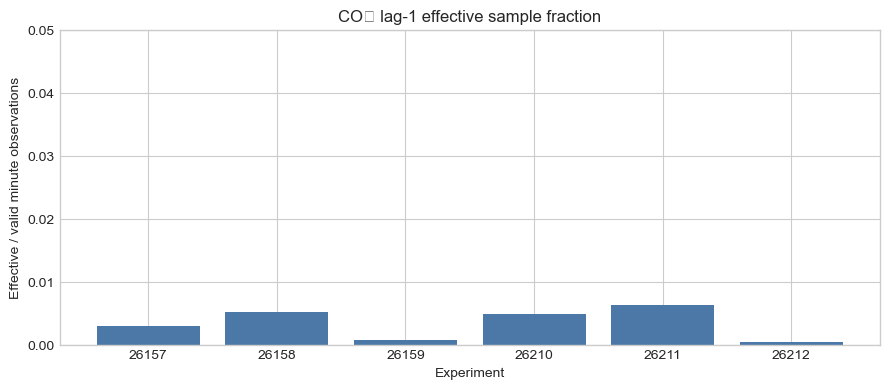

In [4]:
co2_summary = co2.groupby("experiment_id").agg(
    bins=("observed_flow_ln_min", "size"),
    source_valid_minutes=("source_valid_minutes", "first"),
    lag1_autocorrelation=("lag1_autocorrelation", "first"),
    effective_sample_size=("effective_sample_size_minutes", "first"),
    total_likelihood_weight=("likelihood_weight", "sum"),
).reset_index()
co2_summary["effective_fraction"] = co2_summary["effective_sample_size"] / co2_summary["source_valid_minutes"]
display(co2_summary.round(4))
assert not set(co2["experiment_id"].astype(str)).intersection({"26134", "26135", "26136"})
assert np.allclose(co2_summary["effective_sample_size"], co2_summary["total_likelihood_weight"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(co2_summary["experiment_id"].astype(str), co2_summary["effective_fraction"], color="#4c78a8")
ax.set_ylabel("Effective / valid minute observations")
ax.set_xlabel("Experiment")
ax.set_title("CO₂ lag-1 effective sample fraction")
ax.set_ylim(0, max(0.05, co2_summary["effective_fraction"].max() * 1.15))
fig.tight_layout()
plt.show()


### 3. GC censoring and interval capture operators

In [5]:
gc_summary = pd.DataFrame({
    "wine": wine["model_observation_type"].value_counts(),
    "condensate": condensate["mix_model_observation_type"].value_counts(),
}).fillna(0).astype(int)
display(gc_summary)

wine_censored = wine["model_observation_type"].eq("left_censored")
mix_censored = condensate["mix_model_observation_type"].eq("left_censored")
assert wine.loc[wine_censored, "observed_value"].isna().all()
assert wine.loc[wine_censored, "upper_bound"].gt(0).all()
assert condensate.loc[mix_censored, "observed_value"].isna().all()
assert condensate.loc[mix_censored, "upper_bound"].gt(0).all()
assert (condensate["capture_interval_h"] > 0).all()
display(condensate[["experiment_id", "mix_id", "analyte", "capture_interval_start", "capture_interval_end", "capture_interval_h", "observed_value", "upper_bound", "mix_model_observation_type"]].head(12))


,wine,condensate
left_censored,14,122
observed,220,76


,experiment_id,mix_id,analyte,capture_interval_start,capture_interval_end,capture_interval_h,observed_value,upper_bound,mix_model_observation_type
0,26157,26157-MIX-01,Decanoato de Etilo,2026-04-06 13:00:00,2026-04-08 15:00:00,50.0,NaN,0.15125,left_censored
1,26157,26157-MIX-01,Etil Acetato,2026-04-06 13:00:00,2026-04-08 15:00:00,50.0,NaN,2268.75000,left_censored
2,26157,26157-MIX-01,Feniletil Acetato,2026-04-06 13:00:00,2026-04-08 15:00:00,50.0,NaN,60.50000,left_censored
3,26157,26157-MIX-01,Hexil Acetato,2026-04-06 13:00:00,2026-04-08 15:00:00,50.0,0.260887,NaN,observed
4,26157,26157-MIX-01,Isoamil Acetato,2026-04-06 13:00:00,2026-04-08 15:00:00,50.0,NaN,60.50000,left_censored
5,26157,26157-MIX-01,Octanoato de Etilo,2026-04-06 13:00:00,2026-04-08 15:00:00,50.0,NaN,6.05000,left_censored
6,26157,26157-MIX-02,Decanoato de Etilo,2026-04-08 15:00:00,2026-04-10 08:00:00,41.0,0.588976,NaN,observed
7,26157,26157-MIX-02,Etil Acetato,2026-04-08 15:00:00,2026-04-10 08:00:00,41.0,NaN,6562.50000,left_censored
8,26157,26157-MIX-02,Feniletil Acetato,2026-04-08 15:00:00,2026-04-10 08:00:00,41.0,NaN,175.00000,left_censored
9,26157,26157-MIX-02,Hexil Acetato,2026-04-08 15:00:00,2026-04-10 08:00:00,41.0,385.417970,NaN,observed


### 4. Density-trigger timing uncertainty

In [6]:
uncertain = events[events["timing_uncertain"].astype(str).str.lower().eq("true")][
    ["experiment_id", "timestamp", "relative_time_h", "timing_interval_start", "timing_interval_end", "timing_interval_start_h", "timing_interval_end_h", "timing_uncertainty_basis"]
]
display(uncertain)
assert len(uncertain) == 9
assert uncertain[["timing_interval_start", "timing_interval_end"]].notna().all().all()


,experiment_id,timestamp,relative_time_h,timing_interval_start,timing_interval_end,timing_interval_start_h,timing_interval_end_h,timing_uncertainty_basis
2,26134,2026-03-27 16:00:00,48.0,2026-03-27 16:00:00,2026-03-28 08:00:00,48.0,64.0,observed_primary_density_bracket_1040_kg_m3
7,26135,2026-03-27 16:00:00,48.0,2026-03-27 16:00:00,2026-03-28 08:00:00,48.0,64.0,observed_primary_density_bracket_1040_kg_m3
12,26136,2026-03-27 16:00:00,48.0,2026-03-27 08:00:00,2026-03-27 16:00:00,40.0,48.0,observed_primary_density_bracket_1040_kg_m3
17,26157,2026-04-08 16:00:00,51.0,2026-04-08 15:00:00,2026-04-09 08:00:00,50.0,67.0,observed_primary_density_bracket_1040_kg_m3
22,26158,2026-04-08 16:00:00,51.0,2026-04-08 15:00:00,2026-04-09 08:00:00,50.0,67.0,observed_primary_density_bracket_1040_kg_m3
27,26159,2026-04-09 16:00:00,75.0,2026-04-09 15:00:00,2026-04-10 15:00:00,74.0,98.0,observed_primary_density_bracket_1040_kg_m3
32,26210,2026-04-19 16:00:00,48.0,2026-04-19 16:00:00,2026-04-20 08:00:00,48.0,64.0,observed_primary_density_bracket_1040_kg_m3
37,26211,2026-04-19 16:00:00,48.0,2026-04-19 16:00:00,2026-04-20 08:00:00,48.0,64.0,observed_primary_density_bracket_1040_kg_m3
42,26212,2026-04-19 16:00:00,48.0,2026-04-19 08:00:00,2026-04-19 16:00:00,40.0,48.0,observed_primary_density_bracket_1040_kg_m3


### 5. Metadata coverage and carbon diagnostic

,experiment_id,lot,reactor,yeast,storage_history,capture_system,co2_sensor,temperature_sensor,sensor_metadata_status
0,26134,Lote 1,TK-31,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...
1,26135,Lote 1,TK-32,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...
2,26136,Lote 1,TK-33,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...
3,26157,Lote 2,TK-31,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...
4,26158,Lote 2,TK-32,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...
5,26159,Lote 2,TK-33,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...
6,26210,Lote 3,TK-31,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...
7,26211,Lote 3,TK-32,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...
8,26212,Lote 3,TK-33,Zymaflore X5,not_available_in_integration_outputs,two_fraction_condensate_trap_A_plus_B,MassView,Sonda1,signal_identity_confirmed; factory_reference_c...


,experiment_id,initial_observed_carbon_mol_C_l,final_observed_liquid_carbon_mol_C_l,co2_observed_carbon_mol_C_l,partial_observed_carbon_recovery,co2_model_scope,massview_reference_status,diagnostic_status,limitations
0,26134,5.8104,3.8668,0.0000,0.6655,QC_only,owner_estimate_temperature_and_factory_pressur...,not_evaluable,"excludes biomass carbon, unmeasured products, ..."
1,26135,5.7661,3.9082,0.0000,0.6778,QC_only,owner_estimate_temperature_and_factory_pressur...,not_evaluable,"excludes biomass carbon, unmeasured products, ..."
2,26136,5.5836,3.8898,0.0000,0.6966,QC_only,owner_estimate_temperature_and_factory_pressur...,not_evaluable,"excludes biomass carbon, unmeasured products, ..."
3,26157,5.6298,0.0000,1.8033,0.3203,calibration,owner_estimate_temperature_and_factory_pressur...,diagnostic_only_incomplete,"excludes biomass carbon, unmeasured products, ..."
4,26158,5.4671,0.0000,1.8609,0.3404,calibration,owner_estimate_temperature_and_factory_pressur...,diagnostic_only_incomplete,"excludes biomass carbon, unmeasured products, ..."
5,26159,5.5563,3.8694,1.7530,1.0119,calibration,owner_estimate_temperature_and_factory_pressur...,diagnostic_only_incomplete,"excludes biomass carbon, unmeasured products, ..."
6,26210,5.6676,3.8591,1.8755,1.0118,calibration,owner_estimate_temperature_and_factory_pressur...,diagnostic_only_incomplete,"excludes biomass carbon, unmeasured products, ..."
7,26211,5.7703,3.7962,1.8419,0.9771,calibration,owner_estimate_temperature_and_factory_pressur...,diagnostic_only_incomplete,"excludes biomass carbon, unmeasured products, ..."
8,26212,5.6934,3.8483,1.7046,0.9753,calibration,owner_estimate_temperature_and_factory_pressur...,diagnostic_only_incomplete,"excludes biomass carbon, unmeasured products, ..."


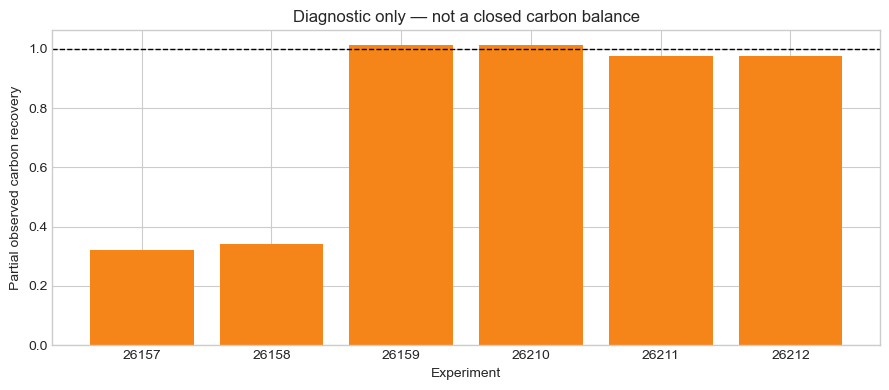

In [7]:
display(metadata[["experiment_id", "lot", "reactor", "yeast", "storage_history", "capture_system", "co2_sensor", "temperature_sensor", "sensor_metadata_status"]])
display(carbon.round(4))

valid_carbon = carbon[carbon["diagnostic_status"].eq("diagnostic_only_incomplete")]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(valid_carbon["experiment_id"].astype(str), valid_carbon["partial_observed_carbon_recovery"], color="#f58518")
ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
ax.set_ylabel("Partial observed carbon recovery")
ax.set_xlabel("Experiment")
ax.set_title("Diagnostic only — not a closed carbon balance")
fig.tight_layout()
plt.show()


### 6. Automated gate table

In [8]:
checks = pd.Series(qc["checks"], name="PASS").to_frame()
display(checks)
assert checks["PASS"].all()
print("PHASE A MODEL-READY ADAPTER: PASS")
print("CALIBRATION GATE: NOT PASSED — owner and repository audit blockers remain")
print("PHYSICAL EXECUTION STATUS: EXPLORATORY ONLY; no schedule issued")


,PASS
active_cooling_separated,True
carbon_diagnostic_present,True
co2_is_downsampled,True
co2_weights_positive,True
condensate_censoring_bounds_complete,True
condensate_intervals_positive,True
density_trigger_uncertainty_explicit,True
excluded_lot1_co2_absent,True
nine_runs,True
sugar_not_double_counted,True


PHASE A MODEL-READY ADAPTER: PASS
CALIBRATION GATE: NOT PASSED — owner and repository audit blockers remain
PHYSICAL EXECUTION STATUS: EXPLORATORY ONLY; no schedule issued


## Takeaways

- The adapter enforces the Pilot 2026 observation contract and fails if Lot 1 CO₂
  re-enters calibration.
- Correlated minute CO₂ data no longer dominate by raw row count.
- GC censoring and interval-condensate accumulation remain explicit in model space.
- Density-triggered second pulses are intervals/latent timing inputs, not exact timestamps.
- Missing storage history and unverified MassView reference conditions remain visible.
- The next authorized step is a **failed/conditional calibration-gate report**, not an
  executable thermal or nutrition schedule.
